# LSEG Daily Returns fuer Euro500 Portfolio (firm_id Cache)

Ziel dieses Notebooks:
- Daily Returns fuer alle Aktien im `euro500` Portfolio ziehen
- Identifier-Fallback robust halten: alle historischen ISIN/RIC je `firm_id`
- Cache **pro Unternehmen (`firm_id`)** statt pro Quartal
- Finale Tabelle nur fuer Tage, an denen die Aktie im Index ist (exakte Mitgliedschaft)


## 1. Setup und Universe laden

- Pfade/Parameter setzen
- `euro500.parquet` laden
- Datentypen bereinigen und `firm_id` als verpflichtenden Schluessel nutzen


In [10]:
from __future__ import annotations

import hashlib
import json
import random
import re
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import lseg.data as ld

import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="lseg")

pd.set_option("display.max_columns", 120)

BASE_DIR = Path("/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data")
DATA_DIR = BASE_DIR / "intermediate"
CACHE_DATA_DIR = BASE_DIR / "cache"
CACHE_DATA_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = BASE_DIR / "tables"

CACHE_DIR = CACHE_DATA_DIR / "daily_returns_cache_by_company"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = CACHE_DATA_DIR / "daily_returns_company_cache_manifest.parquet"
OUTPUT_RETURNS_ALL = DATA_DIR / "daily_returns_company_all.parquet"
OUTPUT_DAILY_RETURNS_EURO500 = DATA_DIR / "euro500_daily_returns.parquet"
OUTPUT_MISSING = DATA_DIR / "daily_returns_missing_companies.parquet"
LEGACY_RETURNS_PATH = DATA_DIR / "rets_daily_isin.parquet"
BAD_IDS_PATH = CACHE_DATA_DIR / "daily_returns_bad_ids.csv"
STEP_ROWS_PATH = CACHE_DATA_DIR / "daily_returns_step_rows.parquet"
STEP_CKPT_PATH = CACHE_DATA_DIR / "daily_returns_step_checkpoint.json"

TARGET_END_DATE = pd.Timestamp("2025-09-30")
BETA_LOOKBACK_MONTHS = 6

EURO500_PATH = DATA_DIR / "euro500.parquet"
if not EURO500_PATH.exists():
    raise FileNotFoundError(f"File not found: {EURO500_PATH}")

df = pd.read_parquet(EURO500_PATH).copy()


## 2. Exakte Mitgliedschaftsfenster je Quartal

Mitgliedschaft pro Zeile gilt von `effective_date` bis einen Tag vor naechster `effective_date`.


In [11]:
quarter_calendar = (
    df[["quarter", "effective_date"]]
    .dropna()
    .drop_duplicates()
    .sort_values("effective_date")
    .reset_index(drop=True)
)
quarter_calendar["next_effective_date"] = quarter_calendar["effective_date"].shift(-1)

# Ende inklusiv: Tag vor naechster effective_date, hart gekappt auf TARGET_END_DATE.
max_end = TARGET_END_DATE
quarter_calendar["membership_end_date"] = quarter_calendar["next_effective_date"] - pd.Timedelta(days=1)
quarter_calendar["membership_end_date"] = quarter_calendar["membership_end_date"].fillna(max_end)
quarter_calendar["membership_end_date"] = quarter_calendar["membership_end_date"].clip(upper=max_end)

membership = df.merge(
    quarter_calendar[["quarter", "effective_date", "membership_end_date"]],
    on=["quarter", "effective_date"],
    how="left",
)

# Avoid duplicate date-column names from upstream inputs.
membership = membership.drop(columns=[c for c in ["start_date", "end_date"] if c in membership.columns])
membership["start_date"] = membership["effective_date"]
membership["end_date"] = membership["membership_end_date"]
membership = membership.drop(columns=["membership_end_date"])

membership = membership.dropna(subset=["firm_id", "start_date", "end_date"]).copy()
membership = membership[membership["start_date"] <= membership["end_date"]].copy()

print("Membership rows:", len(membership))
print("Membership companies:", membership["firm_id"].nunique())
print("Date range:", membership["start_date"].min().date(), "to", membership["end_date"].max().date())


Membership rows: 55500
Membership companies: 1241
Date range: 1998-01-01 to 2025-09-30


## 3. Cache- und Pull-Helfer

- Ein Cache-File pro `firm_id`
- Bei vorhandenem Cache nur fehlende Datumssegmente nachladen


In [12]:
@dataclass
class PullResult:
    df: pd.DataFrame
    field_used: str | None
    mode_used: str | None


def _safe_name(firm_id: str) -> str:
    h = hashlib.sha1(firm_id.encode("utf-8")).hexdigest()[:12]
    clean = re.sub(r"[^A-Za-z0-9._-]", "_", firm_id)
    return f"{clean[:80]}__{h}.parquet"


def cache_path_for_company(firm_id: str) -> Path:
    return CACHE_DIR / _safe_name(firm_id)


def _extract_single_series(raw: pd.DataFrame) -> pd.DataFrame:
    if raw is None or raw.empty:
        return pd.DataFrame(columns=["date", "value"])

    w = raw.copy().reset_index()
    if w.empty:
        return pd.DataFrame(columns=["date", "value"])

    def _col_name(c) -> str:
        if isinstance(c, tuple):
            return " ".join([str(x) for x in c if x is not None]).strip().lower()
        return str(c).strip().lower()

    def _is_date_named(c) -> bool:
        n = _col_name(c)
        return ("date" in n) or ("time" in n) or (n == "index")

    # Date must come from a date/time-named column (or first index column fallback),
    # never from numeric value columns.
    preferred = [c for c in w.columns if _is_date_named(c)]
    candidates = preferred if preferred else [w.columns[0]]

    date_col = None
    best_date_non_na = -1
    for c in candidates:
        d = pd.to_datetime(w[c], errors="coerce")
        n = int(d.notna().sum())
        if n > best_date_non_na:
            best_date_non_na = n
            date_col = c

    if date_col is None or best_date_non_na <= 0:
        return pd.DataFrame(columns=["date", "value"])

    w = w.rename(columns={date_col: "date"})
    w["date"] = pd.to_datetime(w["date"], errors="coerce")
    w = w.dropna(subset=["date"]).copy()

    value_col = None
    best_non_na = -1
    for c in w.columns:
        if c == "date":
            continue
        s_num = pd.to_numeric(w[c], errors="coerce")
        n = int(s_num.notna().sum())
        if n > best_non_na:
            best_non_na = n
            value_col = c

    if value_col is None or best_non_na <= 0:
        return pd.DataFrame(columns=["date", "value"])

    out = w[["date", value_col]].copy()
    out = out.rename(columns={value_col: "value"})
    out["value"] = pd.to_numeric(out["value"], errors="coerce")
    return out.dropna(subset=["value"]).copy()


def _values_to_returns(s: pd.Series, mode: str) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce")

    if mode == "price_level":
        return x.pct_change()

    # mode == return_like: determine percent vs decimal
    abs_q99 = np.nanpercentile(np.abs(x.dropna()), 99) if x.notna().any() else np.nan
    if np.isfinite(abs_q99) and abs_q99 > 1.5:
        return x / 100.0
    return x


def _is_rate_limit_message(msg: str) -> bool:
    m = str(msg).lower()
    return (
        ("too many requests" in m)
        or ("rate limit" in m)
        or ("http 429" in m)
        or ("status 429" in m)
    )


def load_legacy_returns(path: Path) -> pd.DataFrame:
    """
    Normalize existing returns file (rets_daily_isin.parquet) to columns:
    date | pull_id | id_type | ret
    """
    if not path.exists():
        return pd.DataFrame(columns=["date", "pull_id", "id_type", "ret"])

    raw = pd.read_parquet(path).copy()

    date_col = "date" if "date" in raw.columns else None
    if date_col is None:
        for c in raw.columns:
            if "date" in str(c).lower():
                date_col = c
                break
    if date_col is None:
        return pd.DataFrame(columns=["date", "pull_id", "id_type", "ret"])

    id_col = None
    for c in ["ISIN", "isin", "Isin"]:
        if c in raw.columns:
            id_col = c
            break
    if id_col is None:
        return pd.DataFrame(columns=["date", "pull_id", "id_type", "ret"])

    if "ret" in raw.columns:
        ret = pd.to_numeric(raw["ret"], errors="coerce")
    elif "value" in raw.columns:
        v = pd.to_numeric(raw["value"], errors="coerce")
        abs_q99 = np.nanpercentile(np.abs(v.dropna()), 99) if v.notna().any() else np.nan
        ret = v / 100.0 if np.isfinite(abs_q99) and abs_q99 > 1.5 else v
    else:
        return pd.DataFrame(columns=["date", "pull_id", "id_type", "ret"])

    out = pd.DataFrame(
        {
            "date": pd.to_datetime(raw[date_col], errors="coerce"),
            "pull_id": raw[id_col].astype("string").str.strip(),
            "id_type": "ISIN",
            "ret": ret,
        }
    )
    out.loc[out["pull_id"] == "", "pull_id"] = pd.NA
    out = out.dropna(subset=["date", "pull_id", "ret"]).copy()
    out = out.sort_values(["pull_id", "date"]).drop_duplicates(["pull_id", "date"], keep="last")
    return out.reset_index(drop=True)


def pull_one_company_returns(
    pull_id: str,
    start: pd.Timestamp,
    end: pd.Timestamp,
    id_type: str | None = None,
    max_retries: int = 4,
    base_sleep: float = 0.7,
    verbose: bool = False,
) -> PullResult:
    id_type = (id_type or "").upper()
    if id_type == "ISIN":
        plans = [
            ("TR.TotalReturn", "return_like"),
            ("TR.PriceClose", "price_level"),
            ("TRDPRC_1", "price_level"),
        ]
    else:
        plans = [
            ("TR.TotalReturn", "return_like"),
            ("PCTCHNG", "return_like"),
            ("TR.PriceClose", "price_level"),
            ("TRDPRC_1", "price_level"),
        ]

    for field, mode in plans:
        last_err = None
        for r in range(max_retries):
            try:
                raw = ld.get_history(
                    universe=[pull_id],
                    fields=[field],
                    start=start.strftime("%Y-%m-%d"),
                    end=end.strftime("%Y-%m-%d"),
                    interval="daily",
                )
                if verbose:
                    try:
                        print(f"[DEBUG raw] id={pull_id} field={field} shape={getattr(raw, 'shape', None)} cols={list(getattr(raw, 'columns', []))[:8]}")
                    except Exception:
                        pass

                ser = _extract_single_series(raw)
                if verbose:
                    if ser.empty:
                        print(f"[DEBUG ser empty] id={pull_id} field={field}")
                    else:
                        print(f"[DEBUG ser] id={pull_id} field={field} rows={len(ser)} range={ser['date'].min()}:{ser['date'].max()}")

                if ser.empty:
                    break

                ser = ser.sort_values("date")
                ser["ret"] = _values_to_returns(ser["value"], mode=mode)
                ser = ser.dropna(subset=["ret"])[["date", "ret"]].copy()
                if verbose:
                    if ser.empty:
                        print(f"[DEBUG ret empty] id={pull_id} field={field} mode={mode}")
                    else:
                        print(f"[DEBUG ret] id={pull_id} field={field} mode={mode} rows={len(ser)} range={ser['date'].min()}:{ser['date'].max()}")

                if not ser.empty:
                    return PullResult(df=ser, field_used=field, mode_used=mode)
                break
            except Exception as e:
                last_err = e
                if verbose:
                    print(f"[DEBUG exception] id={pull_id} field={field} retry={r+1}/{max_retries} err={e}")
                sleep_s = base_sleep * (2 ** r) + random.random() * 0.3
                time.sleep(sleep_s)

        if last_err is not None:
            if _is_rate_limit_message(str(last_err)):
                # Do not silently downgrade to no-data on 429/rate-limit.
                raise RuntimeError(f"RATE_LIMIT: {last_err}")
            if verbose:
                print(f"[WARN] {pull_id} failed on field {field}: {last_err}")

    return PullResult(df=pd.DataFrame(columns=["date", "ret"]), field_used=None, mode_used=None)


def _load_cache(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=["date", "ret"])
    d = pd.read_parquet(path)
    d["date"] = pd.to_datetime(d["date"], errors="coerce")
    d["ret"] = pd.to_numeric(d["ret"], errors="coerce")
    return d.dropna(subset=["date", "ret"]).sort_values("date").copy()


def _save_cache(path: Path, d: pd.DataFrame) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    d.sort_values("date").drop_duplicates(subset=["date"], keep="last").to_parquet(tmp, index=False)
    tmp.replace(path)


def _normalize_seed(seed_returns: pd.DataFrame | None, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    if seed_returns is None or seed_returns.empty:
        return pd.DataFrame(columns=["date", "ret"])

    x = seed_returns.copy()
    x["date"] = pd.to_datetime(x["date"], errors="coerce")
    x["ret"] = pd.to_numeric(x["ret"], errors="coerce")
    x = x.dropna(subset=["date", "ret"]).copy()
    x = x[(x["date"] >= start) & (x["date"] <= end)].copy()
    x = x.sort_values("date").drop_duplicates(subset=["date"], keep="last")
    return x[["date", "ret"]]


def update_company_cache(
    firm_id: str,
    pull_id: str,
    start: pd.Timestamp,
    end: pd.Timestamp,
    id_type: str | None = None,
    force_refresh: bool = False,
    seed_returns: pd.DataFrame | None = None,
    verbose: bool = False,
) -> tuple[pd.DataFrame, str | None, str | None]:
    path = cache_path_for_company(firm_id)
    cached = pd.DataFrame(columns=["date", "ret"]) if force_refresh else _load_cache(path)

    seed = _normalize_seed(seed_returns, start=start, end=end)
    if not seed.empty:
        frames = [x for x in [cached, seed] if not x.empty]
        if frames:
            cached = pd.concat(frames, ignore_index=True)
        else:
            cached = pd.DataFrame(columns=["date", "ret"])
        cached = cached.sort_values("date").drop_duplicates(subset=["date"], keep="last")

    segments: list[tuple[pd.Timestamp, pd.Timestamp]] = []
    if cached.empty:
        segments.append((start, end))
    else:
        cmin, cmax = cached["date"].min(), cached["date"].max()
        if start < cmin:
            segments.append((start, cmin - pd.Timedelta(days=1)))
        if end > cmax:
            segments.append((cmax + pd.Timedelta(days=1), end))

    pulled_parts = []
    field_used = None
    mode_used = None
    for s, e in segments:
        if s > e:
            continue
        res = pull_one_company_returns(
            pull_id=pull_id,
            start=s,
            end=e,
            id_type=id_type,
            verbose=verbose,
        )
        if not res.df.empty:
            pulled_parts.append(res.df)
        field_used = field_used or res.field_used
        mode_used = mode_used or res.mode_used

    if pulled_parts:
        frames = [x for x in [cached] + pulled_parts if not x.empty]
        if frames:
            all_df = pd.concat(frames, ignore_index=True)
        else:
            all_df = pd.DataFrame(columns=["date", "ret"])
    else:
        all_df = cached.copy()

    all_df = all_df.dropna(subset=["date", "ret"]).sort_values("date")
    all_df = all_df.drop_duplicates(subset=["date"], keep="last")

    if not all_df.empty or force_refresh:
        _save_cache(path, all_df)

    return all_df, field_used, mode_used







## 4. Firmenweise Pull-Map und Fallback-Kandidaten aufbauen

- Pro `firm_id` Pull-Zeitraum bestimmen (inkl. Beta-Lookback)
- Historische Identifier-Liste je Firma aufbauen (ISIN -> RIC_current -> RIC)


In [13]:
company_base = (
    membership[["firm_id"]]
    .dropna(subset=["firm_id"])
    .drop_duplicates(subset=["firm_id"])
    .reset_index(drop=True)
)

# Pull-Zeitraum aus Mitgliedschaftsfenstern je Unternehmen
span = (
    membership.groupby("firm_id", as_index=False)
    .agg(start_date=("start_date", "min"), end_date=("end_date", "max"))
)
span["start_date"] = span["start_date"] - pd.DateOffset(months=BETA_LOOKBACK_MONTHS)
company_pull_map = company_base.merge(span, on="firm_id", how="left")

# Unternehmens-Metadaten fuer bessere Missing-Analyse
meta_cols = [
    c for c in ["firm_id", "name", "ISIN", "RIC", "RIC_current", "hq_country", "hq_code"]
    if c in membership.columns
]
company_meta = (
    membership[meta_cols]
    .dropna(subset=["firm_id"])
    .drop_duplicates(subset=["firm_id"], keep="first")
    .rename(columns={"name": "company_name"})
)
company_pull_map = company_pull_map.merge(company_meta, on="firm_id", how="left")


def _norm_isin(value) -> str:
    if pd.isna(value):
        return ""
    v = str(value).strip()
    if not v:
        return ""
    # Remove repeated ISIN prefixes (e.g., ISIN:ISIN:ES...) and keep the raw code.
    while v.upper().startswith("ISIN:"):
        v = v.split(":", 1)[1].strip()
    return v


def _build_company_candidates(company_req: pd.DataFrame) -> list[tuple[str, str]]:
    """Collect all unique identifiers for one company across time.

    Order (like LSEG_DataPull): all ISINs -> all RIC_current -> all RIC.
    """
    q = company_req.copy().sort_values("start_date", na_position="last")

    out: list[tuple[str, str]] = []
    seen: set[tuple[str, str]] = set()

    def _add(id_type: str, value):
        if pd.isna(value):
            return
        v = str(value).strip()
        if not v:
            return
        key = (id_type, v)
        if key in seen:
            return
        seen.add(key)
        out.append(key)

    # 1) all ISINs observed over time
    if "ISIN" in q.columns:
        for val in q["ISIN"]:
            norm = _norm_isin(val)
            if norm:
                _add("ISIN", norm)
                
    # 2) all current RICs observed over time
    if "RIC_current" in q.columns:
        for val in q["RIC_current"]:
            _add("RIC", val)

    # 3) all legacy/raw RICs observed over time
    if "RIC" in q.columns:
        for val in q["RIC"]:
            _add("RIC", val)

    # Include existing pull_id/id_type history too if present, without creating new pull_id columns.
    if "pull_id" in q.columns and "id_type" in q.columns:
        for id_type, pull_id in zip(q["id_type"], q["pull_id"]):
            it = str(id_type).upper().strip() if pd.notna(id_type) else ""
            if it == "ISIN":
                norm = _norm_isin(pull_id)
                if norm:
                    _add("ISIN", norm)
            elif it == "RIC":
                _add("RIC", pull_id)

    return out


company_candidates_map = {}
for ck, g in membership.groupby("firm_id", sort=False):
    if pd.isna(ck):
        continue
    company_candidates_map[str(ck)] = _build_company_candidates(g)

company_pull_map["id_candidates"] = company_pull_map["firm_id"].astype("string").map(
    lambda ck: company_candidates_map.get(str(ck), [])
)
company_pull_map["n_id_candidates"] = company_pull_map["id_candidates"].apply(len)

legacy_returns = load_legacy_returns(LEGACY_RETURNS_PATH)
legacy_by_id = {}
if not legacy_returns.empty:
    for (id_type, pull_id), g in legacy_returns.groupby(["id_type", "pull_id"], dropna=False):
        legacy_by_id[(id_type, pull_id)] = g[["date", "ret"]].copy()

print("Companies to process:", len(company_pull_map))
print("Legacy rows loaded:", len(legacy_returns))
print("Legacy ids loaded  :", len(legacy_by_id))
print("ID candidates stats:", company_pull_map["n_id_candidates"].describe(), sep="\n")
print(company_pull_map[["firm_id", "firm_id", "n_id_candidates"]].head(3))



Companies to process: 1241
Legacy rows loaded: 0
Legacy ids loaded  : 0
ID candidates stats:
count    1241.000000
mean        2.618050
std         0.860868
min         2.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: n_id_candidates, dtype: float64
       firm_id      firm_id  n_id_candidates
0  FIRM0000557  FIRM0000557                2
1  FIRM0000171  FIRM0000171                2
2  FIRM0000351  FIRM0000351                4


## 5. Cache-Precheck, Pull und Outputs schreiben

- Cache/Seed-Abdeckung je `firm_id` pruefen
- Nur fehlende Segmente aus LSEG nachladen (Fallback ueber Kandidaten)
- Outputs schreiben: Manifest, `daily_returns_company_all`, `daily_returns_missing_companies` (optional)


In [14]:
force_refresh = False
SKIP_LSEG_PULL = False  # True => never call LSEG, build outputs only from existing cache files/seeds.
RETRY_NEEDS_PULL = False  # False => do not re-pull partial-coverage firms; use existing cache only.
PRECHECK_TOL_DAYS = 5
COVERAGE_TOL_DAYS = 5
END_OVERSPAN_DAYS = 5
SKIP_KNOWN_BAD_IDS = True
BAD_ID_COOLDOWN_DAYS = 30
CHECKPOINT_EVERY_N_PULLS = 25
PULL_ABORT_ON_RATE_LIMIT = True
DEBUG_FIRM_IDS = {"FIRM0000999", "FIRM0001007", "FIRM0002607"}

manifest_rows = []
all_company_returns = []
missing_rows = []
bad_rows = []

initial_cache_files = {f.name for f in CACHE_DIR.glob("*.parquet")}
initial_cache_count = len(initial_cache_files)
print(f"Initial cache files: {initial_cache_count}")


def _date_span_from_parquet(path: Path) -> tuple[pd.Timestamp, pd.Timestamp, int]:
    if force_refresh or (not path.exists()):
        return pd.NaT, pd.NaT, 0
    try:
        d = pd.read_parquet(path, columns=["date"])
    except Exception:
        return pd.NaT, pd.NaT, 0

    s = pd.to_datetime(d.get("date"), errors="coerce").dropna()
    if len(s) == 0:
        return pd.NaT, pd.NaT, 0
    return s.min(), s.max(), int(len(s))


def _combine_span(a_min, a_max, b_min, b_max):
    mins = [x for x in [a_min, b_min] if pd.notna(x)]
    maxs = [x for x in [a_max, b_max] if pd.notna(x)]
    cmin = min(mins) if mins else pd.NaT
    cmax = max(maxs) if maxs else pd.NaT
    return cmin, cmax


def _normalize_candidates(cands) -> list[tuple[str, str]]:
    if not isinstance(cands, (list, tuple)):
        return []
    out = []
    seen = set()
    for item in cands:
        if not isinstance(item, (list, tuple)) or len(item) != 2:
            continue
        id_type = str(item[0]).upper().strip()
        pull_id = str(item[1]).strip()
        if not id_type or not pull_id:
            continue

        # Canonicalize ISIN IDs: always bare code without any ISIN: prefixes.
        if id_type == "ISIN":
            while pull_id.upper().startswith("ISIN:"):
                pull_id = pull_id.split(":", 1)[1].strip()
            if not pull_id:
                continue

        key = (id_type, pull_id)
        if key in seen:
            continue
        seen.add(key)
        out.append(key)
    return out



def _seed_from_candidates(id_candidates, start: pd.Timestamp, end: pd.Timestamp) -> tuple[pd.DataFrame, list[str]]:
    parts = []
    sources = []
    for cand_type, cand_id in id_candidates:
        seed_returns = legacy_by_id.get((cand_type, cand_id))
        seed = _normalize_seed(seed_returns, start=start, end=end)
        if seed.empty:
            continue
        s = seed.copy()
        s["_src"] = f"{cand_type}:{cand_id}"
        parts.append(s)
        sources.append(f"{cand_type}:{cand_id}")

    if not parts:
        return pd.DataFrame(columns=["date", "ret"]), []

    all_seed = pd.concat(parts, ignore_index=True)
    all_seed = all_seed.sort_values(["date", "_src"]).drop_duplicates(subset=["date"], keep="last")
    all_seed = all_seed.drop(columns=["_src"])
    return all_seed[["date", "ret"]], sources


def _coverage_rate_pct(data: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp) -> float:
    expected = len(pd.bdate_range(start, end, freq="B"))
    if expected <= 0:
        return float("nan")
    if data is None or data.empty:
        return 0.0
    d = pd.to_datetime(data.get("date"), errors="coerce").dropna()
    if len(d) == 0:
        return 0.0
    observed = int(d.dt.normalize().nunique())
    return round(100.0 * observed / expected, 2)


def _fallbacks_used(id_candidates: list[tuple[str, str]], selected_id_type, selected_pull_id) -> int:
    if not id_candidates or pd.isna(selected_pull_id):
        return -1
    for idx, (t, pid) in enumerate(id_candidates):
        if str(t).upper().strip() == str(selected_id_type).upper().strip() and str(pid).strip() == str(selected_pull_id).strip():
            return idx
    return -1


# ------------------------------
# Pre-check: cache coverage before any pull
# ------------------------------
pre_rows = []
total = len(company_pull_map)
for _, row in company_pull_map.iterrows():
    firm_id = row["firm_id"]
    start = pd.to_datetime(row["start_date"]).normalize()
    end = pd.to_datetime(row["end_date"]).normalize()
    id_candidates = _normalize_candidates(row.get("id_candidates", []))

    seed, seed_sources = _seed_from_candidates(id_candidates, start=start, end=end)

    cache_min, cache_max, cache_rows = _date_span_from_parquet(cache_path_for_company(firm_id))
    seed_min = seed["date"].min() if not seed.empty else pd.NaT
    seed_max = seed["date"].max() if not seed.empty else pd.NaT

    comb_min, comb_max = _combine_span(cache_min, cache_max, seed_min, seed_max)

    if pd.isna(comb_min) or pd.isna(comb_max):
        pre_status = "no_cache"
    elif (comb_min <= start + pd.Timedelta(days=PRECHECK_TOL_DAYS)) and (comb_max >= end - pd.Timedelta(days=PRECHECK_TOL_DAYS)):
        pre_status = "full_coverage"
    else:
        pre_status = "partial_coverage"

    pre_rows.append(
        {
            "firm_id": firm_id,
            "pre_status": pre_status,
            "cache_rows": cache_rows,
            "cache_min": cache_min,
            "cache_max": cache_max,
            "seed_available": bool(not seed.empty),
            "seed_sources": "|".join(seed_sources),
            "combined_min": comb_min,
            "combined_max": comb_max,
        }
    )

precheck_df = pd.DataFrame(pre_rows)
company_pull_map = company_pull_map.merge(precheck_df, on="firm_id", how="left")

status_counts = company_pull_map["pre_status"].value_counts(dropna=False).to_dict()
precheck_status_counts = dict(status_counts)
print("Pre-check status:", status_counts)
print("Pre-check tolerance days:", PRECHECK_TOL_DAYS)

bad_recent_firm_ids = set()
if BAD_IDS_PATH.exists() and SKIP_KNOWN_BAD_IDS and (not force_refresh):
    try:
        bad_hist = pd.read_csv(BAD_IDS_PATH)
        if "firm_id" in bad_hist.columns:
            bad_hist["firm_id"] = bad_hist["firm_id"].astype("string").str.strip()
            bad_hist = bad_hist[bad_hist["firm_id"].notna() & (bad_hist["firm_id"] != "")].copy()
            if "last_failed_at" in bad_hist.columns:
                bad_hist["last_failed_at"] = pd.to_datetime(bad_hist["last_failed_at"], errors="coerce")
                cutoff = pd.Timestamp.now().normalize() - pd.Timedelta(days=BAD_ID_COOLDOWN_DAYS)
                bad_hist = bad_hist[bad_hist["last_failed_at"].notna() & (bad_hist["last_failed_at"] >= cutoff)].copy()
            bad_recent_firm_ids = set(bad_hist["firm_id"].astype(str).tolist())
    except Exception as e:
        print(f"Warning: failed to read bad-id log, ignoring: {e}")


def _upsert_bad_id_record(rec: dict) -> None:
    cols = ["firm_id", "last_failed_at", "reason", "n_candidates", "tried_ids"]
    one = pd.DataFrame([rec], columns=cols)

    if BAD_IDS_PATH.exists():
        try:
            old = pd.read_csv(BAD_IDS_PATH)
        except Exception:
            old = pd.DataFrame(columns=cols)
    else:
        old = pd.DataFrame(columns=cols)

    if old is None or len(old) == 0:
        out = one.copy()
    else:
        out = pd.concat([old, one], ignore_index=True)
    out["firm_id"] = out["firm_id"].astype("string").str.strip()
    out["last_failed_at"] = pd.to_datetime(out["last_failed_at"], errors="coerce").dt.normalize()
    out = out.dropna(subset=["firm_id", "last_failed_at"])
    out = out.sort_values(["firm_id", "last_failed_at"]).drop_duplicates(subset=["firm_id"], keep="last")
    out.to_csv(BAD_IDS_PATH, index=False)


def _is_rate_limit_error(exc: Exception) -> bool:
    msg = str(exc).lower()
    return (
        ("rate_limit" in msg)
        or ("too many requests" in msg)
        or ("rate limit" in msg)
        or ("http 429" in msg)
        or ("status 429" in msg)
    )

if RETRY_NEEDS_PULL:
    pull_statuses = {"no_cache", "partial_coverage"}
else:
    pull_statuses = {"no_cache"}

pull_queue_all = company_pull_map[company_pull_map["pre_status"].isin(pull_statuses)].copy()
known_bad_queue = pull_queue_all.iloc[0:0].copy()
if SKIP_KNOWN_BAD_IDS and (not force_refresh) and bad_recent_firm_ids:
    known_bad_mask = pull_queue_all["firm_id"].astype("string").isin(bad_recent_firm_ids)
    known_bad_queue = pull_queue_all[known_bad_mask].copy()
    pull_queue = pull_queue_all[~known_bad_mask].copy()
else:
    pull_queue = pull_queue_all.copy()

pull_needed = int(len(pull_queue))
print(f"Needs pull: {pull_needed}/{total}")
print("Pull statuses:", sorted(pull_statuses))
print(f"Known bad skipped from pull queue: {len(known_bad_queue)}")

if SKIP_LSEG_PULL:
    print("SKIP_LSEG_PULL=True -> skip all LSEG pulls; build outputs from existing cache/seeds only.")
    pull_queue = pull_queue.iloc[0:0].copy()
    pull_needed = 0


def _record_result(
    row: pd.Series,
    data: pd.DataFrame,
    field_used: str | None,
    mode_used: str | None,
    selected_id_type: str | None,
    selected_pull_id: str | None,
    tried_ids: list[str],
    seed_available: bool,
    fallbacks_used: int,
    coverage_rate_pct: float,
) -> None:
    firm_id = row["firm_id"]
    company_name = row.get("company_name", pd.NA)
    firm_id_meta = row.get("firm_id", pd.NA)
    isin_meta = row.get("ISIN", pd.NA)
    ric_meta = row.get("RIC", pd.NA)
    ric_current_meta = row.get("RIC_current", pd.NA)
    start = pd.to_datetime(row["start_date"]).normalize()
    end = pd.to_datetime(row["end_date"]).normalize()
    pre_status = row.get("pre_status", "partial_coverage")

    if not data.empty:
        data = data.copy()
        data["date"] = pd.to_datetime(data["date"], errors="coerce")
        data = data.dropna(subset=["date", "ret"])
        data = data[(data["date"] >= start) & (data["date"] <= end)].copy()

    if data.empty:
        reason = "no_data"
        if seed_available:
            reason = "no_data_after_seed"
        missing_rows.append(
            {
                "firm_id": firm_id,
                "company_name": company_name,
                "firm_id": firm_id_meta,
                "ISIN": isin_meta,
                "RIC": ric_meta,
                "RIC_current": ric_current_meta,
                "pull_id": selected_pull_id,
                "id_type": selected_id_type,
                "start_date": start,
                "end_date": end,
                "reason": reason,
                "tried_ids": "|".join(tried_ids),
                "fallbacks_used": int(fallbacks_used),
                "coverage_rate_pct": float(coverage_rate_pct) if pd.notna(coverage_rate_pct) else np.nan,
            }
        )
    else:
        tmp = data.copy()
        tmp["firm_id"] = firm_id
        tmp["name"] = company_name
        tmp["pull_id"] = selected_pull_id
        tmp["id_type"] = selected_id_type
        all_company_returns.append(tmp)

    manifest_rows.append(
        {
            "firm_id": firm_id,
            "pull_id": selected_pull_id,
            "id_type": selected_id_type,
            "cache_path": str(cache_path_for_company(firm_id)),
            "pre_status": pre_status,
            "rows": int(len(data)),
            "min_date": data["date"].min() if not data.empty else pd.NaT,
            "max_date": data["date"].max() if not data.empty else pd.NaT,
            "field_used": field_used,
            "mode_used": mode_used,
            "seed_available": bool(seed_available),
            "tried_ids": "|".join(tried_ids),
            "fallbacks_used": int(fallbacks_used),
            "coverage_rate_pct": float(coverage_rate_pct) if pd.notna(coverage_rate_pct) else np.nan,
            "updated_at": pd.Timestamp.now(),
        }
    )


def _save_step_checkpoint(progress_label: str = "") -> None:
    step_rows_df = pd.DataFrame(manifest_rows)
    step_rows_df.to_parquet(STEP_ROWS_PATH, index=False)
    step_ckpt = {
        "processed_companies": sorted(step_rows_df["firm_id"].dropna().astype(str).unique().tolist()),
        "rows": int(len(step_rows_df)),
        "updated_at_utc": pd.Timestamp.utcnow().isoformat(),
    }
    if progress_label:
        step_ckpt["progress_label"] = progress_label
    STEP_CKPT_PATH.write_text(json.dumps(step_ckpt, ensure_ascii=False, indent=2))


# ------------------------------
# Phase 1: cache-only rows (no LSEG pull)
# ------------------------------
if SKIP_LSEG_PULL:
    cache_rows_df = company_pull_map.copy()
    print(f"Cache-only rows (all companies): {len(cache_rows_df)}")
else:
    cache_only_statuses = {"full_coverage"}
    if not RETRY_NEEDS_PULL:
        cache_only_statuses = cache_only_statuses | {"partial_coverage"}
    cache_rows_df = company_pull_map[company_pull_map["pre_status"].isin(cache_only_statuses)].copy()
    print(f"Cache-only rows: {len(cache_rows_df)}")
    print("Cache-only statuses:", sorted(cache_only_statuses))

for _, row in cache_rows_df.iterrows():
    firm_id = row["firm_id"]
    start = pd.to_datetime(row["start_date"]).normalize()
    end = pd.to_datetime(row["end_date"]).normalize()
    id_candidates = _normalize_candidates(row.get("id_candidates", []))

    selected_id_type = id_candidates[0][0] if id_candidates else pd.NA
    selected_pull_id = id_candidates[0][1] if id_candidates else pd.NA
    tried_ids = [f"{t}:{i}" for t, i in id_candidates]

    seed_all, seed_sources = _seed_from_candidates(id_candidates, start=start, end=end)
    seed_available = bool(not seed_all.empty)

    cached = pd.DataFrame(columns=["date", "ret"]) if force_refresh else _load_cache(cache_path_for_company(firm_id))
    frames = [x for x in [cached, seed_all] if not x.empty]
    if frames:
        data = pd.concat(frames, ignore_index=True)
        data = data.dropna(subset=["date", "ret"]).sort_values("date").drop_duplicates(subset=["date"], keep="last")
    else:
        data = pd.DataFrame(columns=["date", "ret"])

    cov_pct = _coverage_rate_pct(data, start=start, end=end)
    fb_used = _fallbacks_used(id_candidates, selected_id_type, selected_pull_id)

    _record_result(
        row=row,
        data=data,
        field_used=None,
        mode_used="cache_only",
        selected_id_type=selected_id_type,
        selected_pull_id=selected_pull_id,
        tried_ids=tried_ids,
        seed_available=seed_available,
        fallbacks_used=fb_used,
        coverage_rate_pct=cov_pct,
    )


# ------------------------------
# Phase 1b: known-bad rows (skip LSEG pull)
# ------------------------------
if len(known_bad_queue) > 0:
    print(f"Known-bad rows handled cache-only: {len(known_bad_queue)}")

for _, row in known_bad_queue.iterrows():
    firm_id = row["firm_id"]
    start = pd.to_datetime(row["start_date"]).normalize()
    end = pd.to_datetime(row["end_date"]).normalize()
    id_candidates = _normalize_candidates(row.get("id_candidates", []))

    selected_id_type = id_candidates[0][0] if id_candidates else pd.NA
    selected_pull_id = id_candidates[0][1] if id_candidates else pd.NA
    tried_ids = [f"{t}:{i}" for t, i in id_candidates]

    seed_all, _ = _seed_from_candidates(id_candidates, start=start, end=end)
    seed_available = bool(not seed_all.empty)

    cached = pd.DataFrame(columns=["date", "ret"]) if force_refresh else _load_cache(cache_path_for_company(firm_id))
    frames = [x for x in [cached, seed_all] if not x.empty]
    if frames:
        data = pd.concat(frames, ignore_index=True)
        data = data.dropna(subset=["date", "ret"]).sort_values("date").drop_duplicates(subset=["date"], keep="last")
    else:
        data = pd.DataFrame(columns=["date", "ret"])

    cov_pct = _coverage_rate_pct(data, start=start, end=end)
    fb_used = _fallbacks_used(id_candidates, selected_id_type, selected_pull_id)

    _record_result(
        row=row,
        data=data,
        field_used=None,
        mode_used="known_bad_skip",
        selected_id_type=selected_id_type,
        selected_pull_id=selected_pull_id,
        tried_ids=tried_ids,
        seed_available=seed_available,
        fallbacks_used=fb_used,
        coverage_rate_pct=cov_pct,
    )


# ------------------------------
# Phase 2: only pull queue (with ID fallback)
# ------------------------------
_save_step_checkpoint("after_cache_phases")

session_open = False
if pull_needed > 0:
    ld.open_session()
    session_open = True

try:
    t0 = time.time()
    pull_total = len(pull_queue)
    milestones = set()
    if pull_total > 0:
        milestones = {max(1, int(np.ceil(pull_total * p / 100.0))) for p in range(5, 101, 5)}

    pull_aborted_on_rate_limit = False
    pull_abort_reason = None

    for pull_idx, (_, row) in enumerate(pull_queue.iterrows(), start=1):
        firm_id = row["firm_id"]
        start = pd.to_datetime(row["start_date"]).normalize()
        end = pd.to_datetime(row["end_date"]).normalize()
        end_pull = end + pd.Timedelta(days=END_OVERSPAN_DAYS)

        id_candidates = _normalize_candidates(row.get("id_candidates", []))
        tried_ids = [f"{t}:{pid}" for t, pid in id_candidates]
        tried_preview = " | ".join(tried_ids[:4]) if tried_ids else "none"
        if len(tried_ids) > 4:
            tried_preview = tried_preview + " | ..."

        seed_all, seed_sources = _seed_from_candidates(id_candidates, start=start, end=end_pull)
        seed_available = bool(not seed_all.empty)

        data = pd.DataFrame(columns=["date", "ret"])
        field_used = None
        mode_used = None
        selected_id_type = pd.NA
        selected_pull_id = pd.NA

        # Try IDs in order; continue fallback until coverage is sufficient.
        for cand_type, cand_id in id_candidates:
            candidate_seed = legacy_by_id.get((cand_type, cand_id))
            is_debug_firm = str(firm_id) in DEBUG_FIRM_IDS
            try:
                cand_data, cand_field, cand_mode = update_company_cache(
                    firm_id=firm_id,
                    pull_id=cand_id,
                    start=start,
                    end=end_pull,
                    id_type=cand_type,
                    force_refresh=force_refresh,
                    seed_returns=candidate_seed,
                    verbose=is_debug_firm,
                )
            except Exception as e:
                if _is_rate_limit_error(e):
                    pull_aborted_on_rate_limit = True
                    pull_abort_reason = str(e)
                    print(f"[RATE LIMIT] aborting pull loop at firm_id={firm_id} candidate={cand_type}:{cand_id} err={e}")
                    break
                raise
            if cand_data.empty:
                if is_debug_firm:
                    print(f"[DEBUG empty] firm_id={firm_id} candidate={cand_type}:{cand_id}")
                continue

            if is_debug_firm:
                ddbg = pd.to_datetime(cand_data.get("date"), errors="coerce")
                print(
                    f"[DEBUG hit] firm_id={firm_id} candidate={cand_type}:{cand_id} rows={len(cand_data)} "
                    f"range={ddbg.min()}:{ddbg.max()} field={cand_field} mode={cand_mode}"
                )

            data = cand_data
            field_used = field_used or cand_field
            mode_used = mode_used or cand_mode
            selected_id_type = cand_type
            selected_pull_id = cand_id

            dmin = pd.to_datetime(data["date"], errors="coerce").min()
            dmax = pd.to_datetime(data["date"], errors="coerce").max()
            if pd.notna(dmin) and pd.notna(dmax):
                if (dmin <= start + pd.Timedelta(days=COVERAGE_TOL_DAYS)) and (dmax >= end - pd.Timedelta(days=COVERAGE_TOL_DAYS)):
                    break

        if pull_aborted_on_rate_limit and PULL_ABORT_ON_RATE_LIMIT:
            _save_step_checkpoint(f"rate_limit_abort_at_{pull_idx}_of_{pull_total}")
            break

        cov_pct = _coverage_rate_pct(data, start=start, end=end)
        fb_used = _fallbacks_used(id_candidates, selected_id_type, selected_pull_id)
        cand_total = int(len(id_candidates))
        if fb_used >= 0:
            cand_used = int(fb_used + 1)
        else:
            cand_used = cand_total if cand_total > 0 else 0
        cand_label = f"{cand_used}/{cand_total}"

        pulled_min = pd.to_datetime(data.get("date"), errors="coerce").min() if not data.empty else pd.NaT
        pulled_max = pd.to_datetime(data.get("date"), errors="coerce").max() if not data.empty else pd.NaT
        pulled_range = (
            f"{pulled_min.date()}:{pulled_max.date()}" if pd.notna(pulled_min) and pd.notna(pulled_max) else "NA:NA"
        )

        index_range = f"{start.date()}:{end.date()}"
        print(
            f"[Pull firm {pull_idx}/{pull_total}] firm_id={str(firm_id)[:40]} | cand_used={cand_label} | coverage={cov_pct:.2f}% | index_range={index_range} | pulled_range={pulled_range} | tried_ids: {tried_preview}"
        )
        if pd.isna(selected_pull_id):
            bad_rec = {
                "firm_id": firm_id,
                "last_failed_at": pd.Timestamp.now().normalize(),
                "reason": "no_data_all_candidates" if len(id_candidates) > 0 else "no_id_candidates",
                "n_candidates": int(len(id_candidates)),
                "tried_ids": "|".join(tried_ids),
            }
            bad_rows.append(bad_rec)
            _upsert_bad_id_record(bad_rec)

        _record_result(
            row=row,
            data=data,
            field_used=field_used,
            mode_used=mode_used,
            selected_id_type=selected_id_type,
            selected_pull_id=selected_pull_id,
            tried_ids=tried_ids,
            seed_available=seed_available,
            fallbacks_used=fb_used,
            coverage_rate_pct=cov_pct,
        )

        done = pull_idx
        should_ckpt = (done % CHECKPOINT_EVERY_N_PULLS == 0) or (done in milestones) or (done == pull_total)
        if should_ckpt:
            _save_step_checkpoint(f"pull_{done}_of_{pull_total}")
        if pull_total > 0 and (done in milestones or done == pull_total):
            elapsed = time.time() - t0
            pct = int(np.floor(100 * done / max(pull_total, 1)))
            print(f"Pull progress: {pct}% ({done}/{pull_total}) | elapsed {elapsed:0.1f}s")

    if pull_aborted_on_rate_limit:
        print("Pull loop stopped early due to rate limit. Remaining firms are left untouched for resume.")
        if pull_abort_reason:
            print("Rate-limit reason:", pull_abort_reason)

finally:
    if session_open:
        ld.close_session()

SAVE_MANIFEST = True  # Persist run diagnostics for QA/debugging.
manifest_df = pd.DataFrame(manifest_rows)
if SAVE_MANIFEST:
    manifest_df.to_parquet(MANIFEST_PATH, index=False)
    print("Saved manifest:", MANIFEST_PATH)
else:
    print("Manifest not saved (SAVE_MANIFEST=False)")

if all_company_returns:
    returns_all = pd.concat(all_company_returns, ignore_index=True)
else:
    returns_all = pd.DataFrame(columns=["date", "ret", "firm_id", "name", "pull_id", "id_type"])

returns_all["date"] = pd.to_datetime(returns_all["date"], errors="coerce")
returns_all = returns_all.dropna(subset=["date"]).copy()
returns_all = returns_all[returns_all["date"] <= TARGET_END_DATE].copy()

returns_all = returns_all.sort_values(["firm_id", "date"]).reset_index(drop=True)
returns_all.to_parquet(OUTPUT_RETURNS_ALL, index=False)
print("Saved company returns:", OUTPUT_RETURNS_ALL, "rows:", len(returns_all))

missing_df = pd.DataFrame(missing_rows)
print("Built missing list in-memory rows:", len(missing_df))

# Persist known no-data ids to avoid repeated futile pulls
bad_new_df = pd.DataFrame(bad_rows)
if BAD_IDS_PATH.exists():
    try:
        bad_old = pd.read_csv(BAD_IDS_PATH)
    except Exception:
        bad_old = pd.DataFrame(columns=["firm_id", "last_failed_at", "reason", "n_candidates", "tried_ids"])
else:
    bad_old = pd.DataFrame(columns=["firm_id", "last_failed_at", "reason", "n_candidates", "tried_ids"])

if len(bad_new_df) > 0:
    if bad_old is None or len(bad_old) == 0:
        bad_all = bad_new_df.copy()
    else:
        bad_all = pd.concat([bad_old, bad_new_df], ignore_index=True)
else:
    bad_all = bad_old.copy()

if len(bad_all) > 0:
    if "firm_id" in bad_all.columns:
        bad_all["firm_id"] = bad_all["firm_id"].astype("string").str.strip()
    bad_all["last_failed_at"] = pd.to_datetime(bad_all.get("last_failed_at"), errors="coerce").dt.normalize()
    bad_all = bad_all.dropna(subset=["firm_id", "last_failed_at"])
    bad_all = bad_all.sort_values(["firm_id", "last_failed_at"]).drop_duplicates(subset=["firm_id"], keep="last")
    bad_all.to_csv(BAD_IDS_PATH, index=False)
print("Updated bad-id log:", BAD_IDS_PATH, "rows:", len(bad_all))

# Persist final step-resume artifacts (rows + checkpoint)
_save_step_checkpoint("final")
print("Saved step rows:", STEP_ROWS_PATH, "rows:", len(manifest_rows))
print("Saved step checkpoint:", STEP_CKPT_PATH)

# Post-check: verify cache persistence after pulls
post_rows = []
for _, row in company_pull_map.iterrows():
    firm_id = row["firm_id"]
    start = pd.to_datetime(row["start_date"]).normalize()
    end = pd.to_datetime(row["end_date"]).normalize()
    id_candidates = _normalize_candidates(row.get("id_candidates", []))

    seed, _ = _seed_from_candidates(id_candidates, start=start, end=end)
    cache_min, cache_max, _ = _date_span_from_parquet(cache_path_for_company(firm_id))
    seed_min = seed["date"].min() if not seed.empty else pd.NaT
    seed_max = seed["date"].max() if not seed.empty else pd.NaT
    comb_min, comb_max = _combine_span(cache_min, cache_max, seed_min, seed_max)

    if pd.isna(comb_min) or pd.isna(comb_max):
        post_status = "no_cache"
    elif (comb_min <= start + pd.Timedelta(days=PRECHECK_TOL_DAYS)) and (comb_max >= end - pd.Timedelta(days=PRECHECK_TOL_DAYS)):
        post_status = "full_coverage"
    else:
        post_status = "partial_coverage"

    post_rows.append({"firm_id": firm_id, "post_status": post_status})

post_df = pd.DataFrame(post_rows)
post_status_counts = post_df["post_status"].value_counts(dropna=False).to_dict()
post_cache_files = {f.name for f in CACHE_DIR.glob("*.parquet")}
new_cache_files = len(post_cache_files - initial_cache_files)

print("Post-check status:", post_status_counts)
print("Full-coverage delta (post - pre):", int(post_status_counts.get("full_coverage", 0) - precheck_status_counts.get("full_coverage", 0)))
print("New cache files created this run:", new_cache_files)
print("Cache files total now:", len(post_cache_files))






Initial cache files: 1199
Pre-check status: {'full_coverage': 677, 'partial_coverage': 514, 'no_cache': 50}
Pre-check tolerance days: 5
Needs pull: 2/1241
Pull statuses: ['no_cache']
Known bad skipped from pull queue: 48
Cache-only rows: 1191
Cache-only statuses: ['full_coverage', 'partial_coverage']
Known-bad rows handled cache-only: 48
[Pull firm 1/2] firm_id=FIRM0000936 | cand_used=2/2 | coverage=96.41% | index_range=2001-01-02:2025-09-30 | pulled_range=2001-06-14:2025-10-03 | tried_ids: ISIN:FR0000044448 | RIC:NEXS.PA
Pull progress: 50% (1/2) | elapsed 29.7s
[Pull firm 2/2] firm_id=FIRM0000928 | cand_used=2/2 | coverage=93.79% | index_range=2001-01-02:2025-09-30 | pulled_range=2001-06-25:2025-10-03 | tried_ids: ISIN:AT0000730007 | RIC:ANDR.VI
Pull progress: 100% (2/2) | elapsed 61.7s
Saved manifest: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/cache/daily_returns_company_cache_manifest.parquet
Saved company returns: /Users/jakob/Documents/

## 6. Exakt auf Index-Mitgliedschaft filtern

`returns_in_index` enthaelt nur Tage, an denen die Aktie im Portfolio/Index enthalten war.


In [17]:
# Expand membership windows to business days for exact day-level filter
m_cols = [
    c for c in ["quarter", "start_date", "end_date", "firm_id", "name", "ISIN", "RIC", "RIC_current"]
    if c in membership.columns
]
m = membership[m_cols].copy()

m = m.dropna(subset=["firm_id", "start_date", "end_date"]).copy()

parts = []
for _, r in m.iterrows():
    dates = pd.bdate_range(r["start_date"], r["end_date"], freq="B")
    if len(dates) == 0:
        continue
    part = pd.DataFrame({"date": dates})
    for c in m_cols:
        if c in {"start_date", "end_date"}:
            continue
        part[c] = r[c]
    parts.append(part)

if parts:
    membership_daily = pd.concat(parts, ignore_index=True)
else:
    membership_daily = pd.DataFrame(columns=["date", "quarter", "firm_id", "name"])

returns_all = pd.read_parquet(OUTPUT_RETURNS_ALL)
returns_all["date"] = pd.to_datetime(returns_all["date"], errors="coerce")
returns_all = returns_all[returns_all["date"] <= TARGET_END_DATE].copy()

ret_cols = [c for c in ["date", "firm_id", "ret", "pull_id", "id_type"] if c in returns_all.columns]
returns_in_index = membership_daily.merge(
    returns_all[ret_cols],
    on=["date", "firm_id"],
    how="left",
    suffixes=("", "_ret"),
)

# keep only dates where we actually have a return
returns_in_index = returns_in_index.dropna(subset=["ret"]).copy()

returns_in_index = returns_in_index.sort_values(["date", "firm_id"]).reset_index(drop=True)

returns_in_index.to_parquet(OUTPUT_DAILY_RETURNS_EURO500, index=False)

print("Built in-index daily returns")
print("Saved:", OUTPUT_DAILY_RETURNS_EURO500)
print("Rows:", len(returns_in_index))
print("Companies covered:", returns_in_index["firm_id"].nunique())
print("Date range:", returns_in_index["date"].min(), "to", returns_in_index["date"].max())


Built in-index daily returns
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_daily_returns.parquet
Rows: 3323199
Companies covered: 1179
Date range: 1998-01-02 00:00:00 to 2025-09-30 00:00:00


## 7. QA: Datenabdeckung

Dieser Block zeigt nur das Wesentliche:
- kompakte KPI-Zusammenfassung zur Coverage
- Verlauf der Coverage-Quote je Quartal
- aufgeteilte Anzahl `abgedeckt` vs. `fehlend` je Quartal


                     metric           value
          Quarters analyzed             110
          Mean coverage (%)           96.25
        Median coverage (%)            96.3
    Quarters < 95% coverage               7
 Worst quarter (coverage %) 1998Q1 (93.60%)
Latest quarter (coverage %) 2025Q2 (96.60%)
   Latest missing companies              17


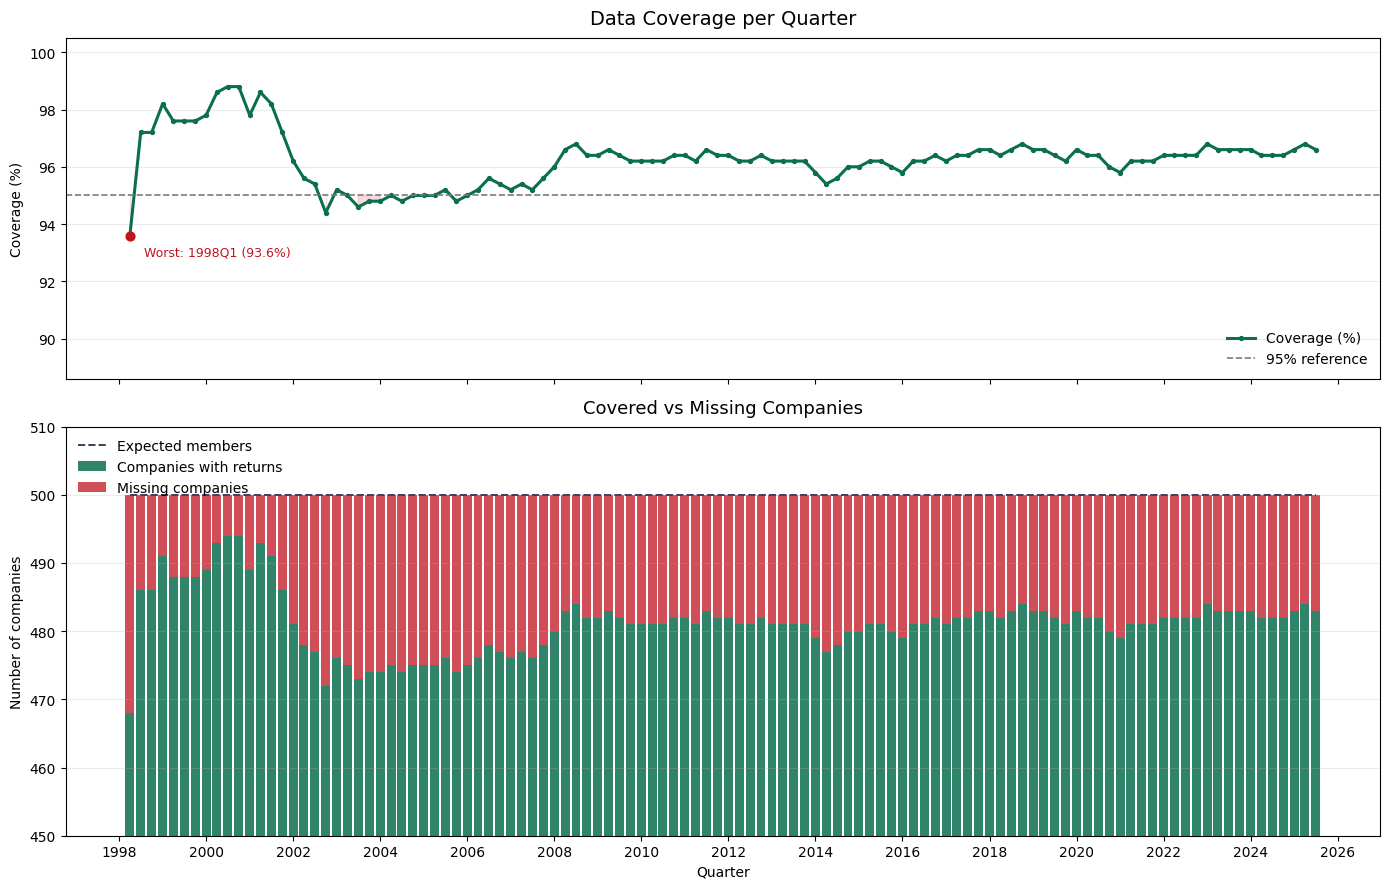

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "returns_in_index" in locals():
    returns_in_index = returns_in_index.copy()
else:
    if not OUTPUT_DAILY_RETURNS_EURO500.exists():
        raise FileNotFoundError(f"File not found: {OUTPUT_DAILY_RETURNS_EURO500}. Run Step 6 first.")
    returns_in_index = pd.read_parquet(OUTPUT_DAILY_RETURNS_EURO500).copy()

returns_in_index["date"] = pd.to_datetime(returns_in_index["date"], errors="coerce")
returns_in_index["quarter"] = returns_in_index["quarter"].astype("string")

# Erwartete Firmenzahl je Quartal aus dem Universe
universe_q = (
    df.groupby("quarter", as_index=False)
    .agg(n_members=("firm_id", "nunique"))
)
universe_q["quarter"] = universe_q["quarter"].astype("string")

coverage_q = (
    returns_in_index
    .groupby("quarter", as_index=False)
    .agg(
        n_obs=("ret", "size"),
        n_companies=("firm_id", "nunique"),
        n_dates=("date", "nunique"),
    )
    .merge(universe_q, on="quarter", how="right")
)

coverage_q["n_obs"] = coverage_q["n_obs"].fillna(0).astype(int)
coverage_q["n_companies"] = coverage_q["n_companies"].fillna(0).astype(int)
coverage_q["n_dates"] = coverage_q["n_dates"].fillna(0).astype(int)
coverage_q["n_members"] = coverage_q["n_members"].fillna(0).astype(int)

coverage_q["missing_companies"] = (coverage_q["n_members"] - coverage_q["n_companies"]).clip(lower=0)
coverage_q["coverage_pct"] = np.where(
    coverage_q["n_members"] > 0,
    100.0 * coverage_q["n_companies"] / coverage_q["n_members"],
    np.nan,
)
coverage_q["avg_obs_per_company"] = np.where(
    coverage_q["n_companies"] > 0,
    coverage_q["n_obs"] / coverage_q["n_companies"],
    np.nan,
)
coverage_q["quarter_end"] = pd.PeriodIndex(coverage_q["quarter"].astype(str), freq="Q").to_timestamp(how="end")
coverage_q = coverage_q[coverage_q["quarter_end"] <= TARGET_END_DATE].copy()
coverage_q = coverage_q.sort_values("quarter_end").reset_index(drop=True)

if coverage_q.empty:
    raise ValueError("coverage_q is empty. Check returns_in_index construction and universe input.")

worst_idx = coverage_q["coverage_pct"].idxmin()
worst = coverage_q.loc[worst_idx]
latest = coverage_q.iloc[-1]

kpi = pd.DataFrame(
    {
        "metric": [
            "Quarters analyzed",
            "Mean coverage (%)",
            "Median coverage (%)",
            "Quarters < 95% coverage",
            "Worst quarter (coverage %)",
            "Latest quarter (coverage %)",
            "Latest missing companies",
        ],
        "value": [
            int(len(coverage_q)),
            round(float(coverage_q["coverage_pct"].mean()), 2),
            round(float(coverage_q["coverage_pct"].median()), 2),
            int((coverage_q["coverage_pct"] < 95).sum()),
            f"{worst['quarter']} ({worst['coverage_pct']:.2f}%)",
            f"{latest['quarter']} ({latest['coverage_pct']:.2f}%)",
            int(latest["missing_companies"]),
        ],
    }
)
print(kpi.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1.2]},
)

# Plot 1: Coverage-Quote
ax1.plot(
    coverage_q["quarter_end"],
    coverage_q["coverage_pct"],
    color="#0B6E4F",
    linewidth=2.2,
    marker="o",
    markersize=2.8,
    label="Coverage (%)",
)
ax1.axhline(95, color="#7A7A7A", linewidth=1.2, linestyle="--", label="95% reference")
ax1.fill_between(
    coverage_q["quarter_end"],
    coverage_q["coverage_pct"],
    95,
    where=coverage_q["coverage_pct"] < 95,
    color="#C1121F",
    alpha=0.15,
)
ax1.scatter([worst["quarter_end"]], [worst["coverage_pct"]], color="#C1121F", s=40, zorder=5)
ax1.annotate(
    f"Worst: {worst['quarter']} ({worst['coverage_pct']:.1f}%)",
    xy=(worst["quarter_end"], worst["coverage_pct"]),
    xytext=(10, -14),
    textcoords="offset points",
    color="#C1121F",
    fontsize=9,
)
ax1.set_title("Data Coverage per Quarter", fontsize=14, pad=10)
ax1.set_ylabel("Coverage (%)")
ax1.set_ylim(max(0, float(np.nanmin(coverage_q["coverage_pct"])) - 5), 100.5)
ax1.grid(axis="y", alpha=0.25)
ax1.legend(loc="lower right", frameon=False)

# Plot 2: Abgedeckte vs fehlende Firmen
ax2.bar(
    coverage_q["quarter_end"],
    coverage_q["n_companies"],
    width=75,
    color="#0B6E4F",
    alpha=0.85,
    label="Companies with returns",
)
ax2.bar(
    coverage_q["quarter_end"],
    coverage_q["missing_companies"],
    width=75,
    bottom=coverage_q["n_companies"],
    color="#C1121F",
    alpha=0.75,
    label="Missing companies",
)
ax2.plot(
    coverage_q["quarter_end"],
    coverage_q["n_members"],
    color="#3D405B",
    linewidth=1.4,
    linestyle="--",
    label="Expected members",
)
ax2.set_title("Covered vs Missing Companies", fontsize=13, pad=10)
ax2.set_ylabel("Number of companies")
ax2.set_xlabel("Quarter")
ax2.set_ylim(450, max(460, int(coverage_q["n_members"].max()) + 10))
ax2.grid(axis="y", alpha=0.25)
ax2.legend(loc="upper left", frameon=False)

ax2.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()


## 8. Top 15 Missing-Unternehmen (meiste Quartale im Index)

Diese Zelle zeigt nur die 15 fehlenden Unternehmen mit den meisten Quartalen im EURO500-Universum.
Ausgabe-Spalten: `name`, `firmid`, `ric`, `isin` sowie `n_quarters_in_index` als Ranking-Metrik.



In [9]:
# Post-Processing only: keine LSEG-Session, kein neuer Datenpull
# NOTE: No additional files are written in this section.

missing_in = OUTPUT_MISSING
euro_in = EURO500_PATH

if not euro_in.exists():
    raise FileNotFoundError(f"euro500 file not found: {euro_in}")

if "missing_df" in locals():
    missing = missing_df.copy()
elif missing_in.exists():
    missing = pd.read_parquet(missing_in).copy()
else:
    missing = pd.DataFrame(columns=["firm_id", "company_name", "ISIN", "RIC", "RIC_current"]) 
    print("No in-memory missing_df and no missing file found; using empty missing list.")

euro = pd.read_parquet(euro_in).copy()

for c in ["firm_id", "ISIN", "RIC", "RIC_current", "name", "quarter"]:
    if c in euro.columns:
        euro[c] = euro[c].astype("string").str.strip()
        euro.loc[euro[c] == "", c] = pd.NA

 # firm_id analog zur Pull-Logik verwenden
if "firm_id" not in euro.columns:
    raise ValueError("Column 'firm_id' missing in euro500 input.")
euro["firm_id"] = euro["firm_id"].astype("string").str.strip()
euro.loc[euro["firm_id"] == "", "firm_id"] = pd.NA

# Quartalsabdeckung je Unternehmen
quarter_counts = (
    euro[["firm_id", "quarter"]]
    .dropna(subset=["firm_id", "quarter"])
    .drop_duplicates()
    .groupby("firm_id", as_index=False)
    .agg(n_quarters_in_index=("quarter", "nunique"))
)

# Metadaten je Unternehmen
meta = (
    euro[["firm_id", "name", "RIC", "RIC_current", "ISIN"]]
    .dropna(subset=["firm_id"])
    .drop_duplicates(subset=["firm_id"], keep="first")
)

missing_enriched = (
    missing.merge(meta, on="firm_id", how="left", suffixes=("", "_meta"))
    .merge(quarter_counts, on="firm_id", how="left")
)

# Fehlende Felder mit Meta-Infos auffuellen
for col in ["firm_id", "ISIN", "RIC", "RIC_current"]:
    mcol = f"{col}_meta"
    if mcol in missing_enriched.columns:
        if col in missing_enriched.columns:
            missing_enriched[col] = missing_enriched[col].fillna(missing_enriched[mcol])
        else:
            missing_enriched[col] = missing_enriched[mcol]

if "name_meta" in missing_enriched.columns:
    name_fallback = missing_enriched["name_meta"].astype("string")
elif "name" in missing_enriched.columns:
    name_fallback = missing_enriched["name"].astype("string")
else:
    name_fallback = pd.Series(pd.NA, index=missing_enriched.index, dtype="string")

if "company_name" in missing_enriched.columns:
    missing_enriched["company_name"] = missing_enriched["company_name"].astype("string").fillna(name_fallback)
else:
    missing_enriched["company_name"] = name_fallback

missing_enriched["n_quarters_in_index"] = missing_enriched["n_quarters_in_index"].fillna(0).astype(int)

# RIC: priorisiere RIC_current, fallback RIC
ric_series = pd.Series(pd.NA, index=missing_enriched.index, dtype="string")
if "RIC_current" in missing_enriched.columns:
    ric_series = missing_enriched["RIC_current"].astype("string")
if "RIC" in missing_enriched.columns:
    ric_series = ric_series.fillna(missing_enriched["RIC"].astype("string"))

result = pd.DataFrame(
    {
        "firm_id": missing_enriched["firm_id"].astype("string") if "firm_id" in missing_enriched.columns else pd.Series(pd.NA, index=missing_enriched.index, dtype="string"),
        "name": missing_enriched["company_name"].astype("string"),
        "firmid": missing_enriched["firm_id"].astype("string") if "firm_id" in missing_enriched.columns else pd.Series(pd.NA, index=missing_enriched.index, dtype="string"),
        "ric": ric_series,
        "isin": missing_enriched["ISIN"].astype("string") if "ISIN" in missing_enriched.columns else pd.Series(pd.NA, index=missing_enriched.index, dtype="string"),
        "n_quarters_in_index": missing_enriched["n_quarters_in_index"],
    }
)

result = (
    result
    .sort_values(["n_quarters_in_index", "name"], ascending=[False, True], na_position="last")
    .drop_duplicates(subset=["firm_id"], keep="first")
    .head(15)
    .reset_index(drop=True)
)

result = result[["name", "firmid", "ric", "isin", "n_quarters_in_index"]]

print(f"Missing firms total: {missing['firm_id'].nunique() if 'firm_id' in missing.columns else len(missing)}")
print("Top 15 missing companies by quarters in index:")
print(result.to_string(index=False))


Missing firms total: 52
Top 15 missing companies by quarters in index:
                                           name      firmid     ric         isin  n_quarters_in_index
                                     Andritz AG FIRM0000928 ANDR.VI AT0000730007                   99
                                      Nexans SA FIRM0000936 NEXS.PA FR0000044448                   99
                                OPAP Holding SA FIRM0000937 OPAr.AT GRS419003009                   99
                       Davide Campari Milano NV FIRM0000943 CPRI.MI IT0003101612                   98
         Motor Oil Hellas Corinth Refineries SA FIRM0000948 MORr.AT GRS426003000                   98
                                       Snam SpA FIRM0000959  SRG.MI IT0003153415                   97
                                   Amplifon SpA FIRM0000927 AMPF.MI IT0003101059                   96
Fraport Frankfurt Airport Services Worldwide AG FIRM0000965 FRAG.DE DE0005773303                   96
           

## 9. Tägliches CAPM-Beta (rolling)

Marktreferenz:
- `market_return_ffmcap_capped80` aus `euro500_index_returns.parquet`

Berechnung:
- Firmenspezifisches, taegliches CAPM-Beta auf rollender Basis
- Standardparameter: `BETA_WINDOW = 252`, `BETA_MIN_OBS = 126`

Nutzen fuer Folgeanalysen:
- Zeitvariierendes Risikomass je Firma
- Struktur- und Kontrollvariable fuer spaetere Querschnitts- und Panelauswertungen


### 9A. Methodik und QC-Regeln der Beta-Schaetzung

Geschaetzt wird ein rolling CAPM-Beta je Firma `i` und Datum `t`:

$$
\beta_{i,t} = \frac{\operatorname{Cov}_{W}(r_i, r_m)}{\operatorname{Var}_{W}(r_m)}
$$

mit:
- `r_i`: taegliche Firmenrendite (`ret`)
- `r_m`: taegliche Marktrendite (`market_ret_cap80`)
- `W`: rollendes Fenster (`252` Handelstage, mind. `126` Beobachtungen)

Momentenbasierte Implementierung:

$$
\operatorname{Cov}_{W}(r_i,r_m)=E_W[r_i r_m]-E_W[r_i]E_W[r_m],
\quad
\operatorname{Var}_{W}(r_m)=E_W[r_m^2]-E_W[r_m]^2
$$

QC-Logik fuer `beta_capm_daily`:
- `n_firms_day >= 300`
- `var_m_roll >= 1e-6`
- `|beta_capm_daily| <= 3`

Wichtig: Bei Verletzung der Regeln werden keine Zeilen geloescht; `beta_capm_daily` wird stattdessen als `NaN` gesetzt.


In [ ]:
MARKET_COL = "market_return_ffmcap_capped80"
BETA_WINDOW = 252
BETA_MIN_OBS = 126

# QC parameter
MIN_FIRMS_DAY = 300
MIN_VAR_M_ROLL = 1e-6
MAX_ABS_BETA = 3.0

MARKET_RETURNS_PATH = DATA_DIR / "euro500_index_returns.parquet"
if not MARKET_RETURNS_PATH.exists():
    raise FileNotFoundError(f"File not found: {MARKET_RETURNS_PATH}")

market_src = pd.read_parquet(MARKET_RETURNS_PATH).copy()
if MARKET_COL not in market_src.columns:
    raise ValueError(f"Missing market column in {MARKET_RETURNS_PATH}: {MARKET_COL}")

if "returns_in_index" in locals():
    daily_returns = returns_in_index.copy()
else:
    if not OUTPUT_DAILY_RETURNS_EURO500.exists():
        raise FileNotFoundError(f"File not found: {OUTPUT_DAILY_RETURNS_EURO500}. Run Step 6 first.")
    daily_returns = pd.read_parquet(OUTPUT_DAILY_RETURNS_EURO500).copy()
daily_returns["date"] = pd.to_datetime(daily_returns["date"], errors="coerce")
daily_returns["ret"] = pd.to_numeric(daily_returns["ret"], errors="coerce")

market_daily = market_src[["date", MARKET_COL]].copy()
market_daily["date"] = pd.to_datetime(market_daily["date"], errors="coerce")
market_daily["market_ret_cap80"] = pd.to_numeric(market_daily[MARKET_COL], errors="coerce")
market_daily = market_daily[["date", "market_ret_cap80"]].drop_duplicates(subset=["date"])

daily_returns = daily_returns.merge(market_daily, on="date", how="left")
daily_returns = daily_returns.sort_values(["date"]).reset_index(drop=True)

# Ensure firm_id exists (backward compatible with older daily_returns files).
if "firm_id" not in daily_returns.columns:
    fid = pd.Series(pd.NA, index=daily_returns.index, dtype="string")
    if "ISIN" in daily_returns.columns:
        v = daily_returns["ISIN"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("ISIN:" + v)
    if "RIC_current" in daily_returns.columns:
        v = daily_returns["RIC_current"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("RIC:" + v)
    if "RIC" in daily_returns.columns:
        v = daily_returns["RIC"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("RIC:" + v)
    if "SEDOL" in daily_returns.columns:
        v = daily_returns["SEDOL"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("SEDOL:" + v)
    daily_returns["firm_id"] = fid
else:
    daily_returns["firm_id"] = daily_returns["firm_id"].astype("string").str.strip()
    daily_returns.loc[daily_returns["firm_id"] == "", "firm_id"] = pd.NA

before_dups = len(daily_returns)
daily_returns = (
    daily_returns
    .dropna(subset=["date", "firm_id"]) 
    .sort_values(["firm_id", "date"], kind="mergesort")
    .drop_duplicates(subset=["firm_id", "date"], keep="last")
    .reset_index(drop=True)
)
print("CAPM input rows (raw -> dedup):", before_dups, "->", len(daily_returns))

daily_returns["ret_x_m"] = daily_returns["ret"] * daily_returns["market_ret_cap80"]
daily_returns["mkt_sq"] = daily_returns["market_ret_cap80"] ** 2

g = daily_returns.groupby("firm_id", group_keys=False, sort=False)
mean_i = g["ret"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m = g["market_ret_cap80"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_im = g["ret_x_m"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m2 = g["mkt_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)

cov_im = mean_im - (mean_i * mean_m)
var_m = mean_m2 - (mean_m ** 2)
daily_returns["var_m_roll"] = var_m

# Raw beta
daily_returns["beta_capm_daily"] = np.where(var_m > 0, cov_im / var_m, np.nan)

# Cross-sectional availability per day (for QC)
n_firms_day = (
    daily_returns.groupby("date", as_index=False)["firm_id"]
    .nunique()
    .rename(columns={"firm_id": "n_firms_day"})
)
daily_returns = daily_returns.merge(n_firms_day, on="date", how="left")

qc_ok = (
    (daily_returns["n_firms_day"] >= MIN_FIRMS_DAY)
    & (daily_returns["var_m_roll"] >= MIN_VAR_M_ROLL)
    & (daily_returns["beta_capm_daily"].abs() <= MAX_ABS_BETA)
)

# Keep rows; only beta becomes empty (NaN) if QC fails.
daily_returns["beta_capm_daily"] = daily_returns["beta_capm_daily"].where(qc_ok, np.nan)

# Final beta series (252d rolling CAPM beta with QC).
daily_returns["beta"] = pd.to_numeric(daily_returns["beta_capm_daily"], errors="coerce")

# Ensure export schema columns exist (missing ones are filled with NA).
export_cols = [
    "date",
    "quarter",
    "name",
    "ISIN",
    "RIC",
    "RIC_current",
    "firm_id",
    "ret",
    "market_ret_cap80",
    "beta",
]
for col in export_cols:
    if col not in daily_returns.columns:
        daily_returns[col] = pd.NA

daily_company_data = daily_returns[export_cols].copy()

DAILY_COMPANY_DATA_PATH = OUTPUT_DAILY_RETURNS_EURO500
daily_company_data.to_parquet(DAILY_COMPANY_DATA_PATH, index=False)

print("Saved:", DAILY_COMPANY_DATA_PATH)
print("Rows:", len(daily_company_data))
print("Date range:", daily_company_data["date"].min(), "to", daily_company_data["date"].max())
print("Beta non-null share (beta):", round(daily_company_data["beta"].notna().mean(), 4))

# Attach latest beta to euro500 using as-of matching (window = 20 days).
BETA_ATTACH_TOL_DAYS = 20


def _clean_id(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip()
    return x.where(x.notna() & (x != ""), pd.NA)


def _resolve_asof_from_euro500(df0: pd.DataFrame) -> pd.Series:
    if "asof_date" in df0.columns:
        return pd.to_datetime(df0["asof_date"], errors="coerce").dt.normalize()
    if "quarter" in df0.columns:
        q = df0["quarter"].astype("string").str.strip()
        dt = pd.Series(pd.NaT, index=q.index, dtype="datetime64[ns]")
        m_q = q.str.match(r"^\d{4}Q[1-4]$", na=False)
        if m_q.any():
            dt.loc[m_q] = pd.PeriodIndex(q[m_q], freq="Q").to_timestamp(how="end")
        m_other = ~m_q
        if m_other.any():
            dt.loc[m_other] = pd.to_datetime(q[m_other], errors="coerce")
        return dt.dt.normalize()
    if "year" in df0.columns:
        y = pd.to_numeric(df0["year"], errors="coerce")
        return pd.to_datetime(y.astype("Int64").astype("string") + "-12-31", errors="coerce").dt.normalize()
    raise ValueError("euro500 has no as-of field (expected asof_date/quarter/year).")


euro500_upd = df.copy()
euro500_upd["asof_date"] = _resolve_asof_from_euro500(euro500_upd)

if "firm_id" not in euro500_upd.columns:
    fid = pd.Series(pd.NA, index=euro500_upd.index, dtype="string")
    if "ISIN" in euro500_upd.columns:
        fid = fid.fillna("ISIN:" + _clean_id(euro500_upd["ISIN"]))
    if "RIC_current" in euro500_upd.columns:
        fid = fid.fillna("RIC:" + _clean_id(euro500_upd["RIC_current"]))
    if "RIC" in euro500_upd.columns:
        fid = fid.fillna("RIC:" + _clean_id(euro500_upd["RIC"]))
    euro500_upd["firm_id"] = fid
else:
    euro500_upd["firm_id"] = _clean_id(euro500_upd["firm_id"])

beta_src = daily_company_data[["date", "beta", "firm_id"]].copy()
beta_src["date"] = pd.to_datetime(beta_src["date"], errors="coerce").dt.normalize()
beta_src["beta"] = pd.to_numeric(beta_src["beta"], errors="coerce")
beta_src["firm_id"] = _clean_id(beta_src["firm_id"])


def _asof_map_by_id(req_df: pd.DataFrame, beta_df: pd.DataFrame, id_col: str, out_col: str) -> pd.DataFrame:
    req_df = req_df.dropna(subset=[id_col, "asof_date"]).copy()
    beta_df = beta_df.dropna(subset=[id_col, "date"]).copy()
    if req_df.empty or beta_df.empty:
        return pd.DataFrame(columns=[id_col, "asof_date", out_col])

    req_df = req_df[[id_col, "asof_date"]].drop_duplicates([id_col, "asof_date"], keep="last")
    beta_df = beta_df[[id_col, "date", "beta"]].drop_duplicates([id_col, "date"], keep="last")

    req_df = req_df.sort_values(["asof_date", id_col], kind="mergesort")
    beta_df = beta_df.sort_values(["date", id_col], kind="mergesort")

    out = pd.merge_asof(
        req_df,
        beta_df,
        left_on="asof_date",
        right_on="date",
        by=id_col,
        direction="backward",
        tolerance=pd.Timedelta(days=BETA_ATTACH_TOL_DAYS),
    )
    return out.rename(columns={"beta": out_col})[[id_col, "asof_date", out_col]]


req_firm = euro500_upd[["firm_id", "asof_date"]].copy()
beta_firm = beta_src[["firm_id", "date", "beta"]].copy()
map_firm = _asof_map_by_id(req_firm, beta_firm, id_col="firm_id", out_col="beta_firm")

euro500_upd = euro500_upd.merge(map_firm, on=["firm_id", "asof_date"], how="left")

old_beta = pd.to_numeric(euro500_upd["beta"], errors="coerce") if "beta" in euro500_upd.columns else pd.Series(np.nan, index=euro500_upd.index)
firm_beta = pd.to_numeric(euro500_upd["beta_firm"], errors="coerce") if "beta_firm" in euro500_upd.columns else pd.Series(np.nan, index=euro500_upd.index)
euro500_upd["beta"] = firm_beta.combine_first(old_beta)

euro500_upd = euro500_upd.drop(columns=[c for c in ["beta_firm"] if c in euro500_upd.columns], errors="ignore")
euro500_upd.to_parquet(EURO500_PATH, index=False)
df = euro500_upd.copy()

print("Updated euro500 with beta (20D as-of window):", EURO500_PATH)
print("euro500 beta non-null share:", round(pd.to_numeric(df["beta"], errors="coerce").notna().mean(), 4))


### 9B. Diagnose der Beta-Qualitaet

Diese Sektion ist rein diagnostisch und veraendert keine Rohdaten.

Geprueft werden:
- Abdeckung: Anteil gueltiger Beta-Beobachtungen
- Stabilitaet: Verteilung und Zeitverlauf der Betas
- Robustheit: Wirkung der QC-Regeln auf Verfuegbarkeit und Ausreisser

Ziel:
- Sicherstellen, dass die Betareihe oekonomisch plausibel und empirisch belastbar ist.


In [ ]:
analysis_df = daily_company_data.copy()
analysis_df = analysis_df.sort_values(["firm_id", "date"]).reset_index(drop=True)

analysis_df["ret"] = pd.to_numeric(analysis_df["ret"], errors="coerce")
analysis_df["market_ret_cap80"] = pd.to_numeric(analysis_df["market_ret_cap80"], errors="coerce")
analysis_df["beta"] = pd.to_numeric(analysis_df["beta"], errors="coerce")

# Implied fit quality: R² aus rolling corr² (pro Firma, selbes Fenster wie Beta).
analysis_df["ret_sq"] = analysis_df["ret"] ** 2
analysis_df["ret_x_m"] = analysis_df["ret"] * analysis_df["market_ret_cap80"]
analysis_df["mkt_sq"] = analysis_df["market_ret_cap80"] ** 2

g = analysis_df.groupby("firm_id", group_keys=False, sort=False)
mean_i = g["ret"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m = g["market_ret_cap80"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_i2 = g["ret_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m2 = g["mkt_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_im = g["ret_x_m"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)

cov_im = mean_im - (mean_i * mean_m)
var_i = mean_i2 - (mean_i ** 2)
var_m = mean_m2 - (mean_m ** 2)
den = np.sqrt(var_i * var_m)
corr_im = np.where(den > 0, cov_im / den, np.nan)
analysis_df["r2_capm_daily"] = np.clip(corr_im ** 2, 0, 1)

analysis_df["ret_hat"] = analysis_df["beta"] * analysis_df["market_ret_cap80"]
analysis_df["resid"] = analysis_df["ret"] - analysis_df["ret_hat"]
analysis_df["abs_err"] = (analysis_df["resid"]).abs()

n_firms_day = (
    analysis_df.groupby("date", as_index=False)["firm_id"]
    .nunique()
    .rename(columns={"firm_id": "n_firms_day"})
)
analysis_df = analysis_df.merge(n_firms_day, on="date", how="left")

summary = pd.DataFrame([
    {
        "rows": len(analysis_df),
        "companies": analysis_df["firm_id"].nunique(),
        "beta_non_null_share": analysis_df["beta"].notna().mean(),
        "r2_non_null_share": analysis_df["r2_capm_daily"].notna().mean(),
        "beta_median": analysis_df["beta"].median(),
        "beta_p10": analysis_df["beta"].quantile(0.10),
        "beta_p90": analysis_df["beta"].quantile(0.90),
        "r2_median": analysis_df["r2_capm_daily"].median(),
        "r2_p90": analysis_df["r2_capm_daily"].quantile(0.90),
        "mae": analysis_df["abs_err"].mean(),
    }
])

print("Gesamt-Diagnostik:")
display(summary)

by_company = (
    analysis_df.groupby("firm_id", as_index=False)
    .agg(
        n_obs=("beta", "size"),
        beta_non_null=("beta", lambda s: s.notna().sum()),
        beta_median=("beta", "median"),
        beta_std=("beta", "std"),
        r2_median=("r2_capm_daily", "median"),
        mae=("abs_err", "mean"),
    )
)
by_company["beta_availability"] = np.where(by_company["n_obs"] > 0, by_company["beta_non_null"] / by_company["n_obs"], np.nan)

print("Schwächste 10 Firmen nach medianem R²:")
display(by_company.sort_values(["r2_median", "beta_availability"]).head(10))

print("Stabilste 10 Firmen (hohes R², hohe Verfügbarkeit):")
display(by_company.sort_values(["r2_median", "beta_availability"], ascending=[False, False]).head(10))


In [ ]:
import matplotlib.pyplot as plt

plot_df = analysis_df.dropna(subset=["date"]).copy()

beta_daily_stats = (
    plot_df.groupby("date", as_index=False)
    .agg(
        beta_median=("beta", "median"),
        beta_p10=("beta", lambda s: s.quantile(0.10)),
        beta_p90=("beta", lambda s: s.quantile(0.90)),
        r2_median=("r2_capm_daily", "median"),
        n_firms=("n_firms_day", "max"),
    )
    .sort_values("date")
)

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

axes[0].plot(beta_daily_stats["date"], beta_daily_stats["beta_median"], lw=1.1, label="Median Beta (QC)")
axes[0].fill_between(
    beta_daily_stats["date"],
    beta_daily_stats["beta_p10"],
    beta_daily_stats["beta_p90"],
    alpha=0.2,
    label="P10-P90 (QC)",
)
axes[0].axhline(1.0, color="black", lw=0.8, alpha=0.7)
axes[0].set_title("Cross-Sectional Beta Over Time (QC)")
axes[0].set_ylabel("beta")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(beta_daily_stats["date"], beta_daily_stats["r2_median"], color="tab:orange", lw=1.1)
axes[1].set_title("Median Rolling R² Over Time")
axes[1].set_ylabel("R²")
axes[1].grid(alpha=0.25)

axes[2].plot(beta_daily_stats["date"], beta_daily_stats["n_firms"], color="tab:green", lw=1.1)
axes[2].set_title("Firms per Day")
axes[2].set_ylabel("count")
axes[2].set_xlabel("date")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(plot_df["beta"].dropna(), bins=80, color="tab:blue", alpha=0.85)
axes[0].axvline(1.0, color="black", lw=0.8)
axes[0].set_title("Distribution: Beta (QC)")
axes[0].set_xlabel("beta")

axes[1].hist(plot_df["r2_capm_daily"].dropna(), bins=80, color="tab:orange", alpha=0.85)
axes[1].set_title("Distribution: Rolling R²")
axes[1].set_xlabel("R²")

plt.tight_layout()
plt.show()
